C:\Users\fabri\AppData\Local\Temp\ipykernel_19760\2496951006.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.xx = self.xx.replace(self.mapping.keys(), self.mapping.values())


cardinality of each feature:
age        76
bp         10
sg          5
al          6
su          6
rbc         2
pc          2
pcc         2
ba          2
bgr       146
bu        118
sc         84
sod        34
pot        40
hemo      115
pcv        42
wbcc       89
rbcc       45
htn         2
dm          2
cad         2
appet       2
pe          2
ane         2
classk      2
dtype: int64
0 158
1 45
2 33
3 37
4 31
5 33
6 12
7 20
8 8
9 12
10 4
11 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    float64
 6   pc      335 non-null    float64
 7   pcc     396 non-null    float64
 8   ba      396 non-null    float64
 9   bgr     356 non-null    float64

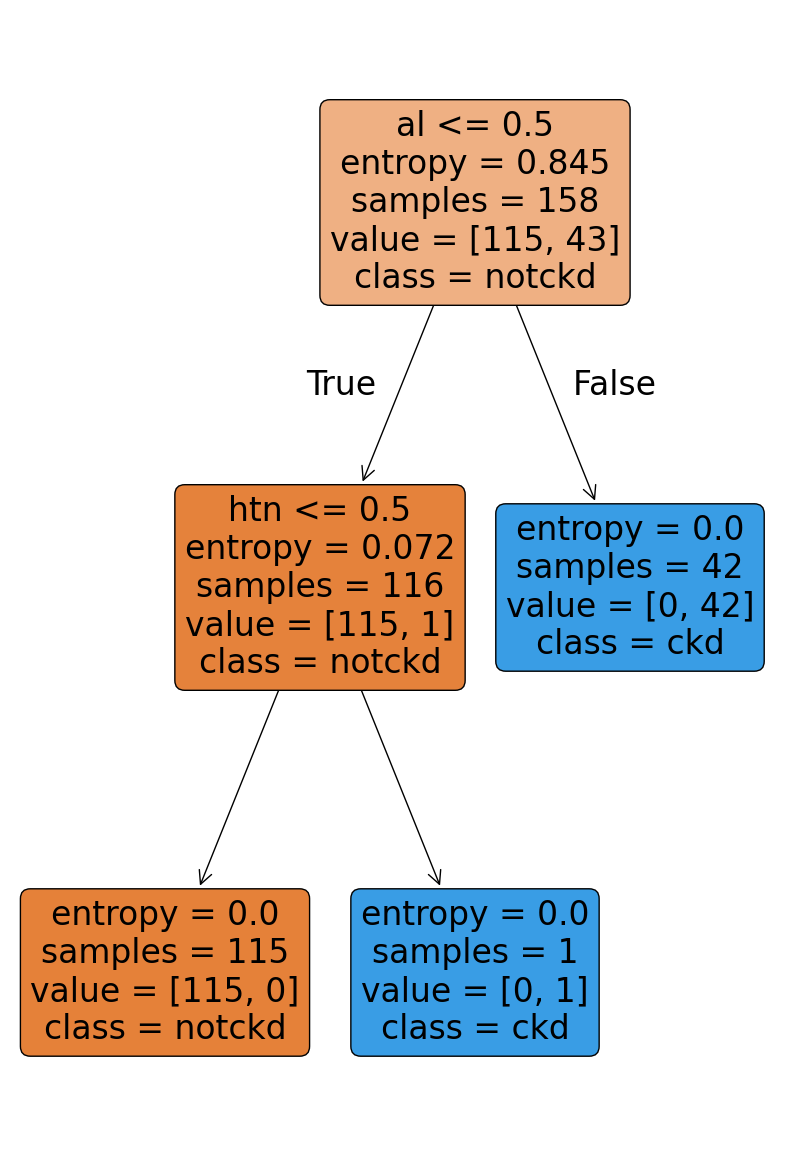


--- Creating Median Imputed Dataset (y_new) ---
y_new shape: (400, 25)

--- Random Forest (n=100) (Train: Xtrain, Test: x_new) ---
Performance of Random Forest (n=100) on x_new:
accuracy = 0.9770773638968482
[[150   0]
 [  8 191]]


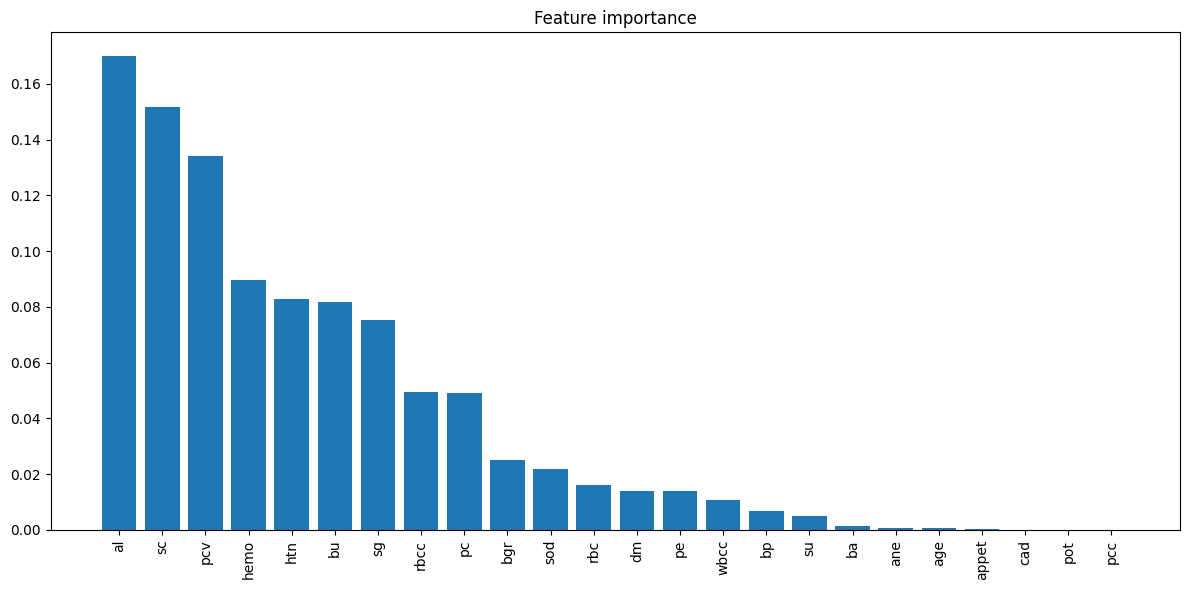


--- Random Forest (n=1000) (Train: Xtrain, Test: x_new) ---
Performance of Random Forest (n=1000) on x_new:
accuracy = 0.9684813753581661
[[150   0]
 [ 11 188]]


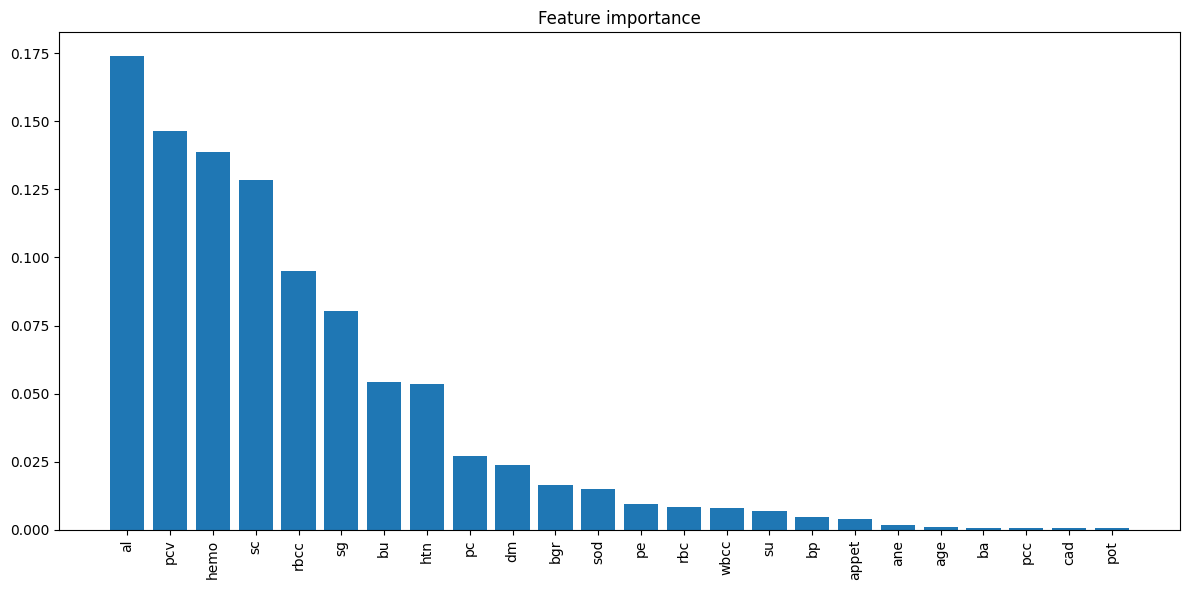


--- Random Forest (n=100) (Train: Xtrain, Test: y_new) ---
Performance of Random Forest (n=100) on y_new:
accuracy = 0.885
[[150   0]
 [ 46 204]]


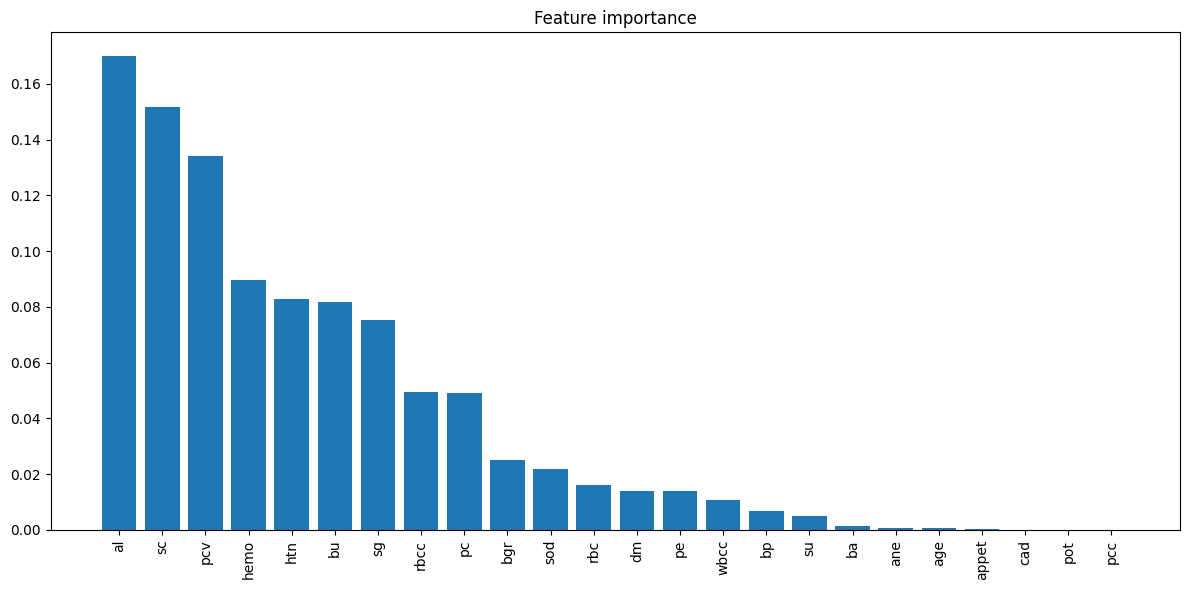


--- Random Forest (n=1000) (Train: Xtrain, Test: y_new) ---
Performance of Random Forest (n=1000) on y_new:
accuracy = 0.8775
[[150   0]
 [ 49 201]]


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.close('all')

class ChronicKidneyDiseaseLab:
    def __init__(self, filepath):
        self.filepath = filepath
        # define the feature names:
        self.feat_names = ['age','bp','sg','al','su','rbc','pc',
                           'pcc','ba','bgr','bu','sc','sod','pot','hemo',
                           'pcv','wbcc','rbcc','htn','dm','cad','appet','pe',
                           'ane','classk'] #numerical
        self.feat_cat = np.array(['num','num','cat','cat','cat','cat','cat','cat','cat',
                                  'num','num','num','num','num','num','num','num','num',
                                  'cat','cat','cat','cat','cat','cat','cat']) # categorical 
        self.target_names = ['notckd','ckd'] # for the final plots
        
        # Mapping for categorical data
        self.mapping = {
            'normal':0, 'abnormal':1, 'present':1, 'notpresent':0,
            'yes':1, ' yes':1, 'no':0, '\tno':0, '\tyes':1,
            'ckd':1, 'notckd':0, 'poor':1, 'good':0, 'ckd\t':1
        }
        
        # Data containers
        self.xx = None      # Original dataframe (mapped)
        self.Xtrain = None  # Training dataset (complete cases)
        self.x_new = None   # Regressed dataset
        self.y_new = None   # Median imputed dataset

    # Loads data, maps categorical values, and prints stats
    def load_and_preprocess(self):
        # import the dataframe:
        self.xx = pd.read_csv(self.filepath, sep=',',
                              skiprows=29, names=self.feat_names, 
                              header=None, na_values=['?','\t?']) #
        
        # change categorical data into numbers:
        self.xx = self.xx.replace(self.mapping.keys(), self.mapping.values())

        print('cardinality of each feature:')
        print(self.xx.nunique()) # show the cardinality of each feature
        
        # Check missing values
        miss_values = self.xx.isnull().sum(axis=1)
        for k in range(miss_values.max()+1):
            print(k, np.sum(miss_values==k))
        print(self.xx.info())
        print(self.xx.describe())

    # Manages missing data through regression (LLS)
    def regression(self, plotCDF=False):
        print("\n--- Performing Regression Imputation ---")
        x = self.xx.copy() 
        x = x.dropna(thresh=19) # drop rows with less than 19 = Nf-6 recorded features
        x.reset_index(drop=True, inplace=True) # necessary to have index without "jumps"
        n = x.isnull().sum(axis=1) # check the number of missing values in each row
        print('Number of points in the original dataset: ', self.xx.shape[0])
        print('reduced dataset: at least 19 values per row')
        print('number of points in the reduced dataset: ', x.shape[0])
        print('max number of missing values in the reduced dataset: ', n.max())
        
        # take the rows with exactly Nf=25 useful features; this is going to be the training dataset for regression
        self.Xtrain = x.dropna(thresh=25) # for training the model we use the rows with all the features
        self.Xtrain.reset_index(drop=True, inplace=True) # reset the index of the dataframe
        print('Number of points in the training dataset: ', self.Xtrain.shape[0])
        
        # normalization
        XtrainNp = self.Xtrain.values # Numpy 2D array
        mm = XtrainNp.mean(axis=0)
        ss = XtrainNp.std(axis=0)
        XtrainNp_norm = (XtrainNp - mm) / ss
        
        # normalize the entire dataset using the coeffs found for the training dataset
        X_normNp = (x.values - mm) / ss
        Np, Nf = X_normNp.shape
        
        # run linear regression using least squares on all the missing data
        for kk in range(Np):
            xrow = X_normNp[kk,:] # k-th row
            mask = np.isnan(xrow) # columns with nan in row k
            Data_tr_norm = XtrainNp_norm[:,~mask] # remove the columns from the training dataset
            y_tr_norm = XtrainNp_norm[:,mask] # columns to be regressed
            w1 = np.linalg.inv(np.dot(Data_tr_norm.T, Data_tr_norm))
            w = np.dot(np.dot(w1, Data_tr_norm.T), y_tr_norm) # weight vector
            ytest_norm = np.dot(xrow[~mask], w)
            xrow[mask] = ytest_norm 
            X_normNp[kk] = xrow # substitute nan with regressed values
        
        x_new_np = X_normNp * ss + mm # denormalize
        
        # manage categorical features
        # get the possible values (i.e. alphabet) for the categorical features
        alphabets = []
        for k in range(len(self.feat_cat)):
            if self.feat_cat[k] == 'cat':
                val = self.Xtrain[self.Xtrain.columns[k]].unique()
                alphabets.append(np.sort(val))
            else:
                alphabets.append('num')
        # ubstitute the regressed numerical values with the closest value in the alphabet
        index = np.argwhere(self.feat_cat == 'cat').flatten()
        for k in index:
            val = alphabets[k].flatten()
            c = x_new_np[:,k]
            val = val.reshape(1,-1) # force row vector
            c = c.reshape(-1,1) # force column vector
            d = (val - c)**2 # find the square distances
            ii = d.argmin(axis=1) # find the closest categorical value
            cc = val[0,ii] # cc contains only the categorical values
            x_new_np[:,k] = cc
        
        self.x_new = pd.DataFrame(x_new_np, columns=self.feat_names) # go back to Pandas dataframe
        
        # check the distributions
        if plotCDF:
            L = self.x_new.shape[0]
            for k in range(Nf):
                plt.figure()
                a = self.xx[self.xx.columns[k]].dropna()
                M = a.shape[0]
                plt.plot(np.sort(a), np.arange(M)/M, label='original dataset')
                plt.plot(np.sort(self.x_new[self.x_new.columns[k]]), np.arange(L)/L, label='regressed dataset')
                plt.title('CDF of ' + self.xx.columns[k])
                plt.xlabel('x')
                plt.ylabel('P(X<=x)')
                plt.grid()
                plt.legend(loc='upper left')
                plt.show()

    # Creates y_new by substituting missing values with median of Xtrain
    def create_median_imputed_dataset(self):
        print("\n--- Creating Median Imputed Dataset (y_new) ---")
        # find the median value of each feature in Xtrain
        medians = self.Xtrain.median()
        # substitute each missing value of the original dataframe x (xx) with the median value
        self.y_new = self.xx.fillna(medians)
        print(f"y_new shape: {self.y_new.shape}")

    #Trains a Decision Tree and evaluates it
    def train_decision_tree(self, train_data, test_data, test_label_name='x_new'):
        print(f"\n--- Decision Tree (Train: Xtrain, Test: {test_label_name}) ---")
        # x_new (complete dataset with the value estimated with LLS) is used as test set
        target = train_data.classk
        inform = train_data.drop('classk', axis=1)

        #Let us use only the complete data (no missing values) to train the decision tree
        clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=4)
        clf = clf.fit(inform, target)
        
        # Prediction
        test_pred = clf.predict(test_data.drop('classk', axis=1))
        
        print(f'Performance of the decision tree on {test_label_name}:')
        print('accuracy =', accuracy_score(test_data.classk, test_pred))
        print(confusion_matrix(test_data.classk, test_pred)) 
        # [TrueNegative, FalsePositive
        #  FalseNegative, Truepositive]
    
        plt.figure(figsize=(10,15))
        tree.plot_tree(clf, feature_names=self.feat_names[:24],
                       class_names=self.target_names, rounded=True,
                       proportion=False, filled=True)
        plt.savefig('decision_tree.png')
        plt.show()

        return clf

    #Trains a Random Forest and evaluates it
    def train_random_forest(self, train_data, test_data, n_estimators, test_label_name):
        print(f"\n--- Random Forest (n={n_estimators}) (Train: Xtrain, Test: {test_label_name}) ---")
        target = train_data.classk
        inform = train_data.drop('classk', axis=1)
        
        rf = RandomForestClassifier(n_estimators=n_estimators, random_state=4)
        rf.fit(inform, target)
        
        test_pred = rf.predict(test_data.drop('classk', axis=1))
        
        print(f'Performance of Random Forest (n={n_estimators}) on {test_label_name}:')
        print('accuracy =', accuracy_score(test_data.classk, test_pred))
        print(confusion_matrix(test_data.classk, test_pred))
        
        importances = rf.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(12, 6))
        plt.title("Feature importance")
        plt.bar(range(len(importances)), importances[indices], align="center")
        plt.xticks(range(len(importances)), [self.feat_names[i] for i in indices], rotation=90)
        plt.tight_layout()
        plt.savefig('features_importance.png')
        plt.show()

        return rf

    #Splits y_new into train/test (50%), shuffles, no random seed
    def run_split_experiment(self):
        print("\n--- Split Experiment on y_new (50% split, no fixed seed) ---")
        
        X = self.y_new.drop('classk', axis=1)
        y = self.y_new['classk']
        
        # Split y_new into training and test subsets (50%), after shuffling.
        # Remove all the settings about the random seed settings.
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True)
        
        # 6.1 Train Random Forest (1000 trees)
        rf = RandomForestClassifier(n_estimators=1000) # No random_state
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        print("Random Forest (1000 trees) on Split Test Set:")
        print('accuracy =', accuracy_score(y_test, y_pred_rf))
        print(confusion_matrix(y_test, y_pred_rf))
        
        # 6.2 Train CART tree classifier
        clf = tree.DecisionTreeClassifier(criterion='entropy') # No random_state
        clf.fit(X_train, y_train)
        y_pred_dt = clf.predict(X_test)
        print("CART Decision Tree on Split Test Set:")
        print('accuracy =', accuracy_score(y_test, y_pred_dt))
        print(confusion_matrix(y_test, y_pred_dt))

    def run(self):
        self.load_and_preprocess()
        self.regression(plotCDF=False) # Step 1 & 2 logic
        
        # Step 2: Get decision tree and accuracy for dataset x_new
        clfXtrain = self.train_decision_tree(self.Xtrain, self.x_new, 'x_new')

        # Step 3: Add a new dataset y_new (median imputation)
        self.create_median_imputed_dataset()
        
        # Step 5: Random Forest (100 and 1000 trees), compare with single tree
        # Using x_new
        rf100 = self.train_random_forest(self.Xtrain, self.x_new, 100, 'x_new')
        rf1000 = self.train_random_forest(self.Xtrain, self.x_new, 1000, 'x_new')
        
        # Using y_new (to compare imputation methods impact)
        self.train_random_forest(self.Xtrain, self.y_new, 100, 'y_new')
        self.train_random_forest(self.Xtrain, self.y_new, 1000, 'y_new')
        
        # Step 6: Split y_new experiment
        self.run_split_experiment()

if __name__ == "__main__":
    # Instantiate and run
    lab = ChronicKidneyDiseaseLab("./data/chronic_kidney_disease_v2.arff")
    lab.run()


